# Uniform HSBM n-scaling spectral clustering

This notebook generates uniform HSBM hypergraphs with `generate_planted_uniform_hsbm_instance`, runs spectral clustering with the Zhou normalized hypergraph Laplacian, and records misclassification rate, ARI, NMI, CPU time, wall-clock time, memory, and algorithm-step runtimes as `n` increases.

Uniform here means every sampled hyperedge has the same size `m`. Edit `CONFIG` or add another `df_n... = run_n_experiment(...)` cell to extend the sweep.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260426-004"
EXPERIMENT_SLUG = "uniform_hsbm_n_scaling_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "\uade0\uc77c HSBM \uc2e4\ud5d8" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260426-004',
 'uniform_hsbm_n_scaling_zhou_laplacian',
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian'))

## Configuration

`a_in`, `b_out`, and `rho_n` are mapped to `p_in = a_in * rho_n / n ** (m - 1)` and `p_out = b_out * rho_n / n ** (m - 1)`, matching the planted d-uniform HSBM model.


In [2]:
CONFIG = {
    "K": 3,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "rho_n": 1.0,
    "reps": 10,
    "seed": 20260426,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_VALUES = list(range(1000, 10001, 1000))

CONFIG, N_VALUES

({'K': 3,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'rho_n': 1.0,
  'reps': 10,
  'seed': 20260426,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

## Helpers

In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_laplacian(L, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(L.shape[0])
    L = ((L + L.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    if n <= K + 1:
        vals, vecs = np.linalg.eigh(L.toarray())
        order = np.argsort(vals)[:K]
        U = vecs[:, order]
    else:
        try:
            v0 = rng.normal(size=n)
            vals, vecs = spla.eigsh(L, k=K, which="SA", tol=eigsh_tol, v0=v0)
            order = np.argsort(vals)
            U = vecs[:, order]
        except Exception as exc:
            warnings.warn(f"eigsh failed ({exc}); falling back to dense eigh.")
            vals, vecs = np.linalg.eigh(L.toarray())
            order = np.argsort(vals)[:K]
            U = vecs[:, order]
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_laplacian_nnz": int(L.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m = int(config["m"])
    seed = int(config["seed"] + 1_000_003 * int(n) + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=float(config["rho_n"]),
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_laplacian(
        L=L,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["rho_n"] = float(config["rho_n"])
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_n_experiment(n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=config)
        rows.append(row)
        print(
            f"n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_n(df_raw):
    return df_raw.groupby("n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## n = 1000

In [4]:
df_n1000 = run_n_experiment(1000)

n= 1000 rep= 1/10 edges=  1197 mis=0.6530 ARI=0.0000 NMI=0.0018 eig=0.012s km=1.550s wall=1.647s peak=0.8MB
n= 1000 rep= 2/10 edges=  1288 mis=0.5030 ARI=0.0784 NMI=0.0718 eig=0.013s km=0.087s wall=0.215s peak=0.8MB
n= 1000 rep= 3/10 edges=  1243 mis=0.5360 ARI=0.0931 NMI=0.0877 eig=0.010s km=0.085s wall=0.191s peak=0.8MB
n= 1000 rep= 4/10 edges=  1305 mis=0.5200 ARI=0.0869 NMI=0.0823 eig=0.012s km=0.115s wall=0.236s peak=0.8MB
n= 1000 rep= 5/10 edges=  1246 mis=0.6340 ARI=0.0026 NMI=0.0236 eig=0.018s km=0.078s wall=0.198s peak=0.8MB
n= 1000 rep= 6/10 edges=  1278 mis=0.3420 ARI=0.2455 NMI=0.2155 eig=0.015s km=0.088s wall=0.229s peak=0.8MB
n= 1000 rep= 7/10 edges=  1241 mis=0.5150 ARI=0.1361 NMI=0.1348 eig=0.017s km=0.090s wall=0.209s peak=0.8MB
n= 1000 rep= 8/10 edges=  1275 mis=0.4840 ARI=0.0962 NMI=0.0868 eig=0.016s km=0.085s wall=0.211s peak=0.8MB
n= 1000 rep= 9/10 edges=  1218 mis=0.5340 ARI=0.0485 NMI=0.0446 eig=0.011s km=0.101s wall=0.213s peak=0.8MB
n= 1000 rep=10/10 edges=  12

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,1000,1,1020263427,3,3,1197,0.653,0.000014,0.001826,0.060085,0.008093,1.561495,0.011714,38,3.591,12.0,8140,0.011723,0.000097,1.549666,1.629665,1.0,0.000036,0.000004,sparse,0.609375,1.647410,0.820516,204.105469,206.515625,2.410156
1,1000,2,1020263428,3,3,1288,0.503,0.078382,0.071825,0.083940,0.007340,0.099963,0.012867,22,3.864,11.0,8684,0.012592,0.000121,0.087237,0.191229,1.0,0.000036,0.000004,sparse,0.609375,0.215198,0.808146,206.515625,206.867188,0.351562
2,1000,3,1020263429,3,3,1243,0.536,0.093078,0.087727,0.069825,0.006854,0.094913,0.011313,21,3.729,11.0,8408,0.010277,0.000071,0.084555,0.171582,1.0,0.000036,0.000004,sparse,0.500000,0.191297,0.798134,206.867188,206.933594,0.066406
3,1000,4,1020263430,3,3,1305,0.520,0.086935,0.082331,0.068773,0.007504,0.127320,0.019641,23,3.915,12.0,8794,0.011988,0.000075,0.115246,0.203585,1.0,0.000036,0.000004,sparse,0.578125,0.235859,0.814805,206.933594,206.941406,0.007812
4,1000,5,1020263431,3,3,1246,0.634,0.002648,0.023564,0.073986,0.008946,0.095509,0.012355,17,3.738,13.0,8432,0.017687,0.000134,0.077673,0.178426,1.0,0.000036,0.000004,sparse,0.656250,0.197779,0.797278,206.941406,206.953125,0.011719
5,1000,6,1020263432,3,3,1278,0.342,0.245533,0.215510,0.086643,0.012232,0.103921,0.014994,20,3.834,10.0,8626,0.015472,0.000087,0.088354,0.202788,1.0,0.000036,0.000004,sparse,0.671875,0.228664,0.809528,206.953125,207.019531,0.066406
6,1000,7,1020263433,3,3,1241,0.515,0.136083,0.134805,0.071260,0.009342,0.107226,0.012965,24,3.723,12.0,8408,0.017317,0.000113,0.089780,0.187811,1.0,0.000036,0.000004,sparse,0.625000,0.208833,0.795953,207.019531,207.031250,0.011719
7,1000,8,1020263434,3,3,1275,0.484,0.096219,0.086815,0.083247,0.007504,0.100927,0.012785,16,3.825,11.0,8598,0.015738,0.000079,0.085097,0.191665,1.0,0.000036,0.000004,sparse,0.562500,0.211153,0.807715,207.031250,207.035156,0.003906
8,1000,9,1020263435,3,3,1218,0.534,0.048462,0.044556,0.072987,0.008439,0.111359,0.011325,25,3.654,12.0,8278,0.010718,0.000078,0.100558,0.192779,1.0,0.000036,0.000004,sparse,0.578125,0.212867,0.791468,207.035156,207.039062,0.003906
9,1000,10,1020263436,3,3,1261,0.574,0.052584,0.057471,0.069443,0.007617,0.125326,0.015297,16,3.783,11.0,8534,0.011978,0.000129,0.113213,0.202379,1.0,0.000036,0.000004,sparse,0.640625,0.228560,0.802538,207.039062,207.269531,0.230469


## n = 2000

In [5]:
df_n2000 = run_n_experiment(2000)

n= 2000 rep= 1/10 edges=  2460 mis=0.5070 ARI=0.1014 NMI=0.0872 eig=0.016s km=0.099s wall=0.350s peak=1.6MB
n= 2000 rep= 2/10 edges=  2538 mis=0.5650 ARI=0.0702 NMI=0.0682 eig=0.014s km=0.084s wall=0.312s peak=1.6MB
n= 2000 rep= 3/10 edges=  2488 mis=0.6145 ARI=0.0120 NMI=0.0141 eig=0.012s km=0.087s wall=0.304s peak=1.6MB
n= 2000 rep= 4/10 edges=  2553 mis=0.4130 ARI=0.1715 NMI=0.1568 eig=0.015s km=0.064s wall=0.277s peak=1.6MB
n= 2000 rep= 5/10 edges=  2521 mis=0.6200 ARI=0.0105 NMI=0.0188 eig=0.012s km=0.072s wall=0.260s peak=1.6MB
n= 2000 rep= 6/10 edges=  2502 mis=0.5710 ARI=0.0423 NMI=0.0515 eig=0.016s km=0.097s wall=0.351s peak=1.6MB
n= 2000 rep= 7/10 edges=  2451 mis=0.6460 ARI=0.0014 NMI=0.0049 eig=0.012s km=0.082s wall=0.277s peak=1.6MB
n= 2000 rep= 8/10 edges=  2548 mis=0.5570 ARI=0.0637 NMI=0.0605 eig=0.014s km=0.087s wall=0.290s peak=1.6MB
n= 2000 rep= 9/10 edges=  2511 mis=0.5135 ARI=0.1146 NMI=0.1202 eig=0.013s km=0.098s wall=0.324s peak=1.6MB
n= 2000 rep=10/10 edges=  26

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,2000,1,2020266427,3,3,2460,0.5070,0.101396,0.087234,0.183200,0.013205,0.114600,0.019784,49,3.6900,11.0,16730,0.015504,0.000082,0.099009,0.311000,1.0,0.000009,0.000001,sparse,0.906250,0.350203,1.598165,207.628906,208.843750,1.214844
1,2000,2,2020266428,3,3,2538,0.5650,0.070197,0.068240,0.160729,0.010965,0.098038,0.021283,45,3.8070,12.0,17186,0.014281,0.000105,0.083646,0.269726,1.0,0.000009,0.000001,sparse,0.828125,0.312271,1.621767,208.843750,209.140625,0.296875
2,2000,3,2020266429,3,3,2488,0.6145,0.012023,0.014053,0.155698,0.011639,0.099916,0.018113,41,3.7320,12.0,16892,0.012469,0.000116,0.087325,0.267248,1.0,0.000009,0.000001,sparse,0.812500,0.304455,1.607218,209.140625,209.171875,0.031250
3,2000,4,2020266430,3,3,2553,0.4130,0.171500,0.156792,0.156650,0.012764,0.079230,0.014946,40,3.8295,12.0,17278,0.015369,0.000156,0.063696,0.248635,1.0,0.000009,0.000001,sparse,0.734375,0.276527,1.625964,209.171875,209.480469,0.308594
4,2000,5,2020266431,3,3,2521,0.6200,0.010525,0.018833,0.133157,0.011183,0.084082,0.014471,33,3.7815,11.0,17078,0.012010,0.000078,0.071990,0.228417,1.0,0.000009,0.000001,sparse,0.687500,0.259742,1.616918,209.480469,209.480469,0.000000
5,2000,6,2020266432,3,3,2502,0.5710,0.042335,0.051507,0.180026,0.014310,0.113010,0.023240,41,3.7530,12.0,16972,0.015835,0.000109,0.097060,0.307340,1.0,0.000009,0.000001,sparse,0.921875,0.351419,1.612754,209.480469,209.480469,0.000000
6,2000,7,2020266433,3,3,2451,0.6460,0.001406,0.004918,0.133535,0.011659,0.094603,0.019528,52,3.6765,12.0,16656,0.012161,0.000092,0.082345,0.239792,1.0,0.000009,0.000001,sparse,0.812500,0.277463,1.598269,209.480469,209.531250,0.050781
7,2000,8,2020266434,3,3,2548,0.5570,0.063740,0.060460,0.142891,0.011518,0.101364,0.016443,40,3.8220,11.0,17246,0.013812,0.000091,0.087456,0.255768,1.0,0.000009,0.000001,sparse,0.812500,0.289918,1.625004,209.531250,209.531250,0.000000
8,2000,9,2020266435,3,3,2511,0.5135,0.114599,0.120209,0.163241,0.011830,0.111109,0.019126,46,3.7665,12.0,17036,0.012900,0.000091,0.098113,0.286176,1.0,0.000009,0.000001,sparse,0.828125,0.324044,1.613983,209.531250,209.531250,0.000000
9,2000,10,2020266436,3,3,2606,0.5220,0.078755,0.069972,0.144407,0.012088,0.103902,0.018246,49,3.9090,12.0,17590,0.016895,0.000095,0.086906,0.260391,1.0,0.000009,0.000001,sparse,0.843750,0.297680,1.642127,209.531250,209.531250,0.000000


## n = 3000

In [6]:
df_n3000 = run_n_experiment(3000)

n= 3000 rep= 1/10 edges=  3694 mis=0.6320 ARI=0.0041 NMI=0.0082 eig=0.014s km=0.122s wall=0.401s peak=2.4MB
n= 3000 rep= 2/10 edges=  3844 mis=0.6370 ARI=0.0041 NMI=0.0083 eig=0.014s km=0.075s wall=0.355s peak=2.4MB
n= 3000 rep= 3/10 edges=  3742 mis=0.4690 ARI=0.1377 NMI=0.1170 eig=0.020s km=0.064s wall=0.331s peak=2.4MB
n= 3000 rep= 4/10 edges=  3741 mis=0.5853 ARI=0.0310 NMI=0.0255 eig=0.014s km=0.089s wall=0.374s peak=2.4MB
n= 3000 rep= 5/10 edges=  3706 mis=0.6333 ARI=0.0018 NMI=0.0134 eig=0.014s km=0.056s wall=0.307s peak=2.4MB
n= 3000 rep= 6/10 edges=  3903 mis=0.5433 ARI=0.0689 NMI=0.0768 eig=0.015s km=0.068s wall=0.341s peak=2.5MB
n= 3000 rep= 7/10 edges=  3698 mis=0.5890 ARI=0.0174 NMI=0.0366 eig=0.014s km=0.087s wall=0.361s peak=2.4MB
n= 3000 rep= 8/10 edges=  3723 mis=0.5733 ARI=0.0394 NMI=0.0438 eig=0.020s km=0.070s wall=0.340s peak=2.4MB
n= 3000 rep= 9/10 edges=  3793 mis=0.4917 ARI=0.1100 NMI=0.0973 eig=0.024s km=0.104s wall=0.387s peak=2.4MB
n= 3000 rep=10/10 edges=  37

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,3000,1,3020269427,3,3,3694,0.632000,0.004100,0.008220,0.204898,0.014407,0.135581,0.024970,82,3.694,12.0,25124,0.013806,0.000066,0.121704,0.354881,1.0,0.000004,4.444444e-07,sparse,1.187500,0.401471,2.403557,209.531250,210.554688,1.023438
1,3000,2,3020269428,3,3,3844,0.637000,0.004071,0.008301,0.213172,0.015506,0.088862,0.018005,68,3.844,12.0,26026,0.014136,0.000080,0.074641,0.317535,1.0,0.000004,4.444444e-07,sparse,0.828125,0.354597,2.448039,210.554688,211.925781,1.371094
2,3000,3,3020269429,3,3,3742,0.469000,0.137655,0.116985,0.194538,0.014987,0.083983,0.019604,55,3.742,11.0,25424,0.019786,0.000086,0.064107,0.293503,1.0,0.000004,4.444444e-07,sparse,0.796875,0.331071,2.420997,211.925781,210.937500,-0.988281
3,3000,4,3020269430,3,3,3741,0.585333,0.031023,0.025548,0.204840,0.016745,0.103633,0.021209,75,3.741,11.0,25396,0.014197,0.000088,0.089343,0.325212,1.0,0.000004,4.444444e-07,sparse,1.015625,0.374255,2.417538,210.937500,211.316406,0.378906
4,3000,5,3020269431,3,3,3706,0.633333,0.001819,0.013353,0.182506,0.015141,0.070413,0.020879,77,3.706,11.0,25190,0.014087,0.000086,0.056235,0.268055,1.0,0.000004,4.444444e-07,sparse,0.703125,0.307114,2.408487,211.316406,211.332031,0.015625
5,3000,6,3020269432,3,3,3903,0.543333,0.068939,0.076773,0.205717,0.016128,0.083355,0.017159,70,3.903,11.0,26360,0.015340,0.000087,0.067922,0.305195,1.0,0.000004,4.444444e-07,sparse,0.812500,0.341132,2.463763,211.332031,211.339844,0.007812
6,3000,7,3020269433,3,3,3698,0.589000,0.017366,0.036578,0.195194,0.014960,0.100811,0.023374,73,3.698,12.0,25156,0.014160,0.000082,0.086564,0.310960,1.0,0.000004,4.444444e-07,sparse,1.046875,0.361291,2.407180,211.339844,211.347656,0.007812
7,3000,8,3020269434,3,3,3723,0.573333,0.039355,0.043762,0.189968,0.014976,0.090086,0.022314,92,3.723,11.0,25294,0.019579,0.000082,0.070421,0.295026,1.0,0.000004,4.444444e-07,sparse,0.906250,0.339750,2.413703,211.347656,211.402344,0.054688
8,3000,9,3020269435,3,3,3793,0.491667,0.109980,0.097336,0.194769,0.017196,0.127922,0.020974,72,3.793,12.0,25716,0.023765,0.000088,0.104064,0.339882,1.0,0.000004,4.444444e-07,sparse,0.984375,0.386620,2.433740,211.402344,211.558594,0.156250
9,3000,10,3020269436,3,3,3772,0.618667,0.010696,0.010175,0.208050,0.016724,0.096283,0.017637,76,3.772,13.0,25596,0.016275,0.000097,0.079906,0.321051,1.0,0.000004,4.444444e-07,sparse,0.937500,0.357421,2.429450,211.558594,211.789062,0.230469


## n = 4000

In [7]:
df_n4000 = run_n_experiment(4000)

n= 4000 rep= 1/10 edges=  5048 mis=0.6643 ARI=-0.0000 NMI=0.0003 eig=0.016s km=0.044s wall=0.386s peak=3.2MB
n= 4000 rep= 2/10 edges=  4961 mis=0.5425 ARI=0.0461 NMI=0.0606 eig=0.023s km=0.115s wall=0.481s peak=3.2MB
n= 4000 rep= 3/10 edges=  5055 mis=0.6365 ARI=0.0048 NMI=0.0089 eig=0.018s km=0.073s wall=0.440s peak=3.2MB
n= 4000 rep= 4/10 edges=  5037 mis=0.6112 ARI=0.0061 NMI=0.0107 eig=0.018s km=0.084s wall=0.436s peak=3.2MB
n= 4000 rep= 5/10 edges=  5022 mis=0.5403 ARI=0.0459 NMI=0.0550 eig=0.021s km=0.094s wall=0.454s peak=3.2MB
n= 4000 rep= 6/10 edges=  5125 mis=0.6562 ARI=0.0006 NMI=0.0085 eig=0.016s km=0.054s wall=0.419s peak=3.3MB
n= 4000 rep= 7/10 edges=  5038 mis=0.5445 ARI=0.0619 NMI=0.0664 eig=0.024s km=0.089s wall=0.451s peak=3.2MB
n= 4000 rep= 8/10 edges=  4994 mis=0.6350 ARI=0.0033 NMI=0.0030 eig=0.020s km=0.077s wall=0.445s peak=3.2MB
n= 4000 rep= 9/10 edges=  5064 mis=0.6400 ARI=0.0034 NMI=0.0118 eig=0.018s km=0.075s wall=0.433s peak=3.3MB
n= 4000 rep=10/10 edges=  5

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,4000,1,4020272427,3,3,5048,0.66425,-0.000016,0.000288,0.255690,0.021072,0.060323,0.023791,101,3.78600,13.0,34242,0.015730,0.000092,0.044496,0.337080,1.0,0.000002,2.500000e-07,sparse,0.750000,0.385703,3.244360,211.789062,212.625000,0.835938
1,4000,2,4020272428,3,3,4961,0.54250,0.046055,0.060599,0.261952,0.020570,0.137153,0.033232,77,3.72075,12.0,33732,0.022503,0.000105,0.114540,0.419670,1.0,0.000002,2.500000e-07,sparse,1.343750,0.481292,3.220915,212.625000,212.160156,-0.464844
2,4000,3,4020272429,3,3,5055,0.63650,0.004840,0.008865,0.262189,0.018394,0.091441,0.031260,92,3.79125,12.0,34300,0.018103,0.000089,0.073244,0.372019,1.0,0.000002,2.500000e-07,sparse,1.046875,0.439536,3.247738,212.160156,212.792969,0.632812
3,4000,4,4020272430,3,3,5037,0.61125,0.006122,0.010726,0.260254,0.018573,0.102225,0.026158,84,3.77775,14.0,34180,0.017729,0.000075,0.084416,0.381047,1.0,0.000002,2.500000e-07,sparse,1.062500,0.436067,3.241660,212.792969,212.019531,-0.773438
4,4000,5,4020272431,3,3,5022,0.54025,0.045901,0.055016,0.262418,0.019152,0.114449,0.027330,86,3.76650,15.0,34100,0.020801,0.000083,0.093560,0.396014,1.0,0.000002,2.500000e-07,sparse,1.156250,0.453735,3.238630,212.019531,212.640625,0.621094
5,4000,6,4020272432,3,3,5125,0.65625,0.000554,0.008514,0.271439,0.019082,0.069430,0.028625,105,3.84375,12.0,34700,0.015524,0.000104,0.053797,0.359946,1.0,0.000002,2.500000e-07,sparse,0.921875,0.419386,3.267594,212.640625,211.957031,-0.683594
6,4000,7,4020272433,3,3,5038,0.54450,0.061903,0.066360,0.265754,0.018409,0.112700,0.024885,79,3.77850,12.0,34170,0.023974,0.000088,0.088632,0.396857,1.0,0.000002,2.500000e-07,sparse,1.156250,0.450760,3.241699,211.957031,213.332031,1.375000
7,4000,8,4020272434,3,3,4994,0.63500,0.003325,0.003042,0.273844,0.018622,0.097311,0.024198,100,3.74550,12.0,33930,0.020266,0.000078,0.076962,0.389772,1.0,0.000002,2.500000e-07,sparse,0.984375,0.445036,3.232591,213.332031,212.664062,-0.667969
8,4000,9,4020272435,3,3,5064,0.64000,0.003398,0.011815,0.268087,0.018956,0.092685,0.026279,99,3.79800,11.0,34330,0.018049,0.000092,0.074540,0.379723,1.0,0.000002,2.500000e-07,sparse,1.062500,0.433335,3.250671,212.664062,213.285156,0.621094
9,4000,10,4020272436,3,3,5122,0.63725,0.002479,0.006297,0.268368,0.019919,0.121433,0.030527,90,3.84150,12.0,34690,0.016215,0.000094,0.105118,0.409713,1.0,0.000002,2.500000e-07,sparse,1.343750,0.475159,3.268457,213.285156,213.285156,0.000000


## n = 5000

In [8]:
df_n5000 = run_n_experiment(5000)

n= 5000 rep= 1/10 edges=  6170 mis=0.6022 ARI=0.0166 NMI=0.0191 eig=0.020s km=0.084s wall=0.562s peak=4.0MB
n= 5000 rep= 2/10 edges=  6201 mis=0.6578 ARI=0.0005 NMI=0.0042 eig=0.017s km=0.080s wall=0.520s peak=4.0MB
n= 5000 rep= 3/10 edges=  6349 mis=0.6318 ARI=0.0042 NMI=0.0225 eig=0.023s km=0.089s wall=0.634s peak=4.1MB
n= 5000 rep= 4/10 edges=  6310 mis=0.6622 ARI=-0.0000 NMI=0.0010 eig=0.018s km=0.060s wall=0.503s peak=4.1MB
n= 5000 rep= 5/10 edges=  6087 mis=0.5976 ARI=0.0227 NMI=0.0273 eig=0.023s km=0.096s wall=0.531s peak=4.0MB
n= 5000 rep= 6/10 edges=  6261 mis=0.6620 ARI=0.0000 NMI=0.0012 eig=0.017s km=0.081s wall=0.536s peak=4.0MB
n= 5000 rep= 7/10 edges=  6332 mis=0.6488 ARI=0.0014 NMI=0.0048 eig=0.024s km=0.086s wall=0.557s peak=4.1MB
n= 5000 rep= 8/10 edges=  6201 mis=0.6610 ARI=0.0002 NMI=0.0028 eig=0.021s km=0.069s wall=0.515s peak=4.0MB
n= 5000 rep= 9/10 edges=  6569 mis=0.5718 ARI=0.0433 NMI=0.0373 eig=0.020s km=0.074s wall=0.565s peak=4.1MB
n= 5000 rep=10/10 edges=  6

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020275427,3,3,6170,0.6022,0.016562,0.019053,0.365944,0.022464,0.104331,0.037497,112,3.7020,13.0,41982,0.019817,0.000099,0.084411,0.492735,1.0,0.000001,1.600000e-07,sparse,1.265625,0.562385,4.017076,213.285156,213.507812,0.222656
1,5000,2,5020275428,3,3,6201,0.6578,0.000494,0.004156,0.330420,0.023226,0.097761,0.036031,127,3.7206,12.0,42168,0.017422,0.000104,0.080231,0.451403,1.0,0.000001,1.600000e-07,sparse,1.234375,0.519524,4.027966,213.507812,214.273438,0.765625
2,5000,3,5020275429,3,3,6349,0.6318,0.004219,0.022497,0.427841,0.022719,0.112310,0.036202,124,3.8094,12.0,43052,0.022983,0.000104,0.089218,0.562866,1.0,0.000001,1.600000e-07,sparse,1.312500,0.634110,4.070893,214.273438,214.203125,-0.070312
3,5000,4,5020275430,3,3,6310,0.6622,-0.000001,0.000984,0.336806,0.024068,0.077629,0.031762,110,3.7860,12.0,42802,0.017600,0.000120,0.059904,0.438498,1.0,0.000001,1.600000e-07,sparse,1.046875,0.502886,4.059900,214.203125,213.515625,-0.687500
4,5000,5,5020275431,3,3,6087,0.5976,0.022668,0.027317,0.323795,0.021823,0.119317,0.030082,146,3.6522,13.0,41480,0.023144,0.000103,0.096065,0.464930,1.0,0.000001,1.600000e-07,sparse,1.328125,0.530520,3.993025,213.515625,215.054688,1.539062
5,5000,6,5020275432,3,3,6261,0.6620,0.000043,0.001234,0.334870,0.022892,0.098528,0.035510,118,3.7566,12.0,42528,0.017244,0.000098,0.081180,0.456285,1.0,0.000001,1.600000e-07,sparse,1.328125,0.535630,4.042780,215.054688,214.679688,-0.375000
6,5000,7,5020275433,3,3,6332,0.6488,0.001440,0.004837,0.360350,0.023368,0.109623,0.031000,110,3.7992,11.0,42932,0.023620,0.000098,0.085900,0.493335,1.0,0.000001,1.600000e-07,sparse,1.250000,0.557032,4.064434,214.679688,214.671875,-0.007812
7,5000,8,5020275434,3,3,6201,0.6610,0.000174,0.002752,0.335074,0.024426,0.090383,0.031776,145,3.7206,12.0,42176,0.021346,0.000129,0.068901,0.449876,1.0,0.000001,1.600000e-07,sparse,1.218750,0.515020,4.028401,214.671875,214.679688,0.007812
8,5000,9,5020275435,3,3,6569,0.5718,0.043317,0.037310,0.381542,0.027708,0.094001,0.026667,103,3.9414,12.0,44362,0.020167,0.000103,0.073726,0.503246,1.0,0.000001,1.600000e-07,sparse,1.125000,0.564621,4.135808,214.679688,214.484375,-0.195312
9,5000,10,5020275436,3,3,6181,0.4960,0.087201,0.082344,0.326624,0.023154,0.103742,0.035746,122,3.7086,12.0,42052,0.027536,0.000102,0.076098,0.453515,1.0,0.000001,1.600000e-07,sparse,1.203125,0.527504,4.019651,214.484375,214.488281,0.003906


## n = 6000

In [9]:
df_n6000 = run_n_experiment(6000)

n= 6000 rep= 1/10 edges=  7572 mis=0.6557 ARI=0.0002 NMI=0.0018 eig=0.023s km=0.063s wall=0.567s peak=4.9MB
n= 6000 rep= 2/10 edges=  7550 mis=0.6098 ARI=0.0078 NMI=0.0251 eig=0.031s km=0.101s wall=0.633s peak=4.9MB
n= 6000 rep= 3/10 edges=  7565 mis=0.6532 ARI=0.0004 NMI=0.0045 eig=0.019s km=0.076s wall=0.574s peak=4.9MB
n= 6000 rep= 4/10 edges=  7644 mis=0.6565 ARI=0.0006 NMI=0.0049 eig=0.020s km=0.084s wall=0.601s peak=4.9MB
n= 6000 rep= 5/10 edges=  7473 mis=0.6588 ARI=0.0003 NMI=0.0045 eig=0.023s km=0.074s wall=0.608s peak=4.8MB
n= 6000 rep= 6/10 edges=  7541 mis=0.6453 ARI=0.0010 NMI=0.0068 eig=0.020s km=0.076s wall=0.582s peak=4.9MB
n= 6000 rep= 7/10 edges=  7634 mis=0.6107 ARI=0.0142 NMI=0.0117 eig=0.020s km=0.076s wall=0.593s peak=4.9MB
n= 6000 rep= 8/10 edges=  7579 mis=0.6462 ARI=0.0014 NMI=0.0077 eig=0.022s km=0.101s wall=0.617s peak=4.9MB
n= 6000 rep= 9/10 edges=  7622 mis=0.6502 ARI=0.0006 NMI=0.0130 eig=0.022s km=0.074s wall=0.648s peak=4.9MB
n= 6000 rep=10/10 edges=  77

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,6000,1,6020278427,3,3,7572,0.655667,0.000231,0.001780,0.376080,0.027021,0.086423,0.038226,125,3.7860,12.0,51396,0.022839,0.000088,0.063492,0.489520,1.0,0.000001,1.111111e-07,sparse,1.265625,0.566972,4.875954,214.488281,208.996094,-5.492188
1,6000,2,6020278428,3,3,7550,0.609833,0.007794,0.025075,0.394925,0.027820,0.131626,0.038265,140,3.7750,15.0,51262,0.030603,0.000096,0.100922,0.554366,1.0,0.000001,1.111111e-07,sparse,1.468750,0.632987,4.865844,208.996094,208.929688,-0.066406
2,6000,3,6020278429,3,3,7565,0.653167,0.000406,0.004450,0.380570,0.027567,0.095455,0.034213,140,3.7825,12.0,51334,0.019317,0.000115,0.076018,0.503587,1.0,0.000001,1.111111e-07,sparse,1.265625,0.574264,4.871302,208.929688,214.105469,5.175781
3,6000,4,6020278430,3,3,7644,0.656500,0.000611,0.004870,0.391309,0.027550,0.103818,0.037570,125,3.8220,12.0,51828,0.019626,0.000155,0.084033,0.522673,1.0,0.000001,1.111111e-07,sparse,1.390625,0.601092,4.896218,214.105469,214.492188,0.386719
4,6000,5,6020278431,3,3,7473,0.658833,0.000271,0.004534,0.394166,0.027259,0.096474,0.036798,130,3.7365,12.0,50794,0.022767,0.000183,0.073517,0.517892,1.0,0.000001,1.111111e-07,sparse,1.390625,0.608143,4.844017,214.492188,213.953125,-0.539062
5,6000,6,6020278432,3,3,7541,0.645333,0.000987,0.006766,0.388039,0.027942,0.096107,0.034345,131,3.7705,14.0,51200,0.020444,0.000100,0.075559,0.512083,1.0,0.000001,1.111111e-07,sparse,1.265625,0.582418,4.865140,213.953125,214.109375,0.156250
6,6000,7,6020278433,3,3,7634,0.610667,0.014161,0.011733,0.397113,0.028021,0.095638,0.034059,130,3.8170,15.0,51778,0.019750,0.000106,0.075778,0.520768,1.0,0.000001,1.111111e-07,sparse,1.265625,0.592981,4.890882,214.109375,214.117188,0.007812
7,6000,8,6020278434,3,3,7579,0.646167,0.001436,0.007701,0.386005,0.027546,0.124072,0.041121,138,3.7895,13.0,51422,0.022474,0.000109,0.101451,0.537585,1.0,0.000001,1.111111e-07,sparse,1.468750,0.617445,4.876266,214.117188,214.113281,-0.003906
8,6000,9,6020278435,3,3,7622,0.650167,0.000645,0.012957,0.429906,0.028629,0.096012,0.043594,128,3.8110,13.0,51690,0.022056,0.000102,0.073849,0.554542,1.0,0.000001,1.111111e-07,sparse,1.484375,0.647602,4.886189,214.113281,213.851562,-0.261719
9,6000,10,6020278436,3,3,7752,0.661000,0.000226,0.003710,0.406243,0.028403,0.080870,0.036251,136,3.8760,14.0,52486,0.020044,0.000116,0.060704,0.515510,1.0,0.000001,1.111111e-07,sparse,1.187500,0.592985,4.925978,213.851562,213.847656,-0.003906


## n = 7000

In [10]:
df_n7000 = run_n_experiment(7000)

n= 7000 rep= 1/10 edges=  8762 mis=0.6633 ARI=-0.0000 NMI=0.0005 eig=0.021s km=0.059s wall=0.637s peak=5.7MB
n= 7000 rep= 2/10 edges=  8788 mis=0.6501 ARI=0.0007 NMI=0.0040 eig=0.025s km=0.080s wall=0.685s peak=5.7MB
n= 7000 rep= 3/10 edges=  8799 mis=0.6627 ARI=0.0000 NMI=0.0006 eig=0.021s km=0.058s wall=0.663s peak=5.7MB
n= 7000 rep= 4/10 edges=  8965 mis=0.6616 ARI=0.0000 NMI=0.0013 eig=0.025s km=0.050s wall=0.658s peak=5.7MB
n= 7000 rep= 5/10 edges=  8798 mis=0.6383 ARI=0.0023 NMI=0.0064 eig=0.032s km=0.080s wall=0.690s peak=5.7MB
n= 7000 rep= 6/10 edges=  9003 mis=0.6229 ARI=0.0090 NMI=0.0166 eig=0.028s km=0.083s wall=0.704s peak=5.7MB
n= 7000 rep= 7/10 edges=  8824 mis=0.6604 ARI=0.0001 NMI=0.0037 eig=0.024s km=0.065s wall=0.673s peak=5.7MB
n= 7000 rep= 8/10 edges=  8876 mis=0.6416 ARI=0.0020 NMI=0.0081 eig=0.021s km=0.080s wall=0.673s peak=5.7MB
n= 7000 rep= 9/10 edges=  8929 mis=0.6639 ARI=0.0000 NMI=0.0007 eig=0.036s km=0.059s wall=0.679s peak=5.7MB
n= 7000 rep=10/10 edges=  8

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,7000,1,7020281427,3,3,8762,0.663286,-0.000003,0.000513,0.437003,0.030186,0.079679,0.039546,173,3.755143,13.0,59514,0.020818,0.000120,0.058737,0.546864,1.0,7.346939e-07,8.163265e-08,sparse,1.328125,0.636720,5.666064,213.863281,214.699219,0.835938
1,7000,2,7020281428,3,3,8788,0.650143,0.000726,0.004026,0.464098,0.030220,0.104682,0.036577,176,3.766286,15.0,59686,0.024535,0.000108,0.080034,0.598996,1.0,7.346939e-07,8.163265e-08,sparse,1.359375,0.685471,5.671647,214.699219,214.683594,-0.015625
2,7000,3,7020281429,3,3,8799,0.662714,0.000028,0.000612,0.456807,0.030068,0.079272,0.047508,172,3.771000,12.0,59748,0.021464,0.000103,0.057660,0.566103,1.0,7.346939e-07,8.163265e-08,sparse,1.359375,0.663229,5.676511,214.683594,213.593750,-1.089844
3,7000,4,7020281430,3,3,8965,0.661571,0.000029,0.001323,0.462089,0.032360,0.074907,0.044155,153,3.842143,12.0,60760,0.024665,0.000125,0.050113,0.569351,1.0,7.346939e-07,8.163265e-08,sparse,1.359375,0.657737,5.726708,213.593750,214.218750,0.625000
4,7000,5,7020281431,3,3,8798,0.638286,0.002264,0.006362,0.458788,0.031037,0.112341,0.038437,164,3.770571,12.0,59734,0.032046,0.000122,0.080166,0.602160,1.0,7.346939e-07,8.163265e-08,sparse,1.406250,0.690070,5.675370,214.218750,214.046875,-0.171875
5,7000,6,7020281432,3,3,9003,0.622857,0.008968,0.016562,0.464475,0.031375,0.111460,0.048630,152,3.858429,12.0,60958,0.027957,0.000119,0.083343,0.607270,1.0,7.346939e-07,8.163265e-08,sparse,1.562500,0.703710,5.735814,214.046875,215.714844,1.667969
6,7000,7,7020281433,3,3,8824,0.660429,0.000078,0.003704,0.455242,0.030962,0.088801,0.045400,174,3.781714,14.0,59904,0.024187,0.000105,0.064503,0.574999,1.0,7.346939e-07,8.163265e-08,sparse,1.406250,0.673405,5.683469,215.714844,216.257812,0.542969
7,7000,8,7020281434,3,3,8876,0.641571,0.002026,0.008078,0.456040,0.031892,0.101303,0.041341,123,3.804000,12.0,60208,0.021342,0.000114,0.079841,0.589228,1.0,7.346939e-07,8.163265e-08,sparse,1.437500,0.673436,5.697817,216.257812,215.371094,-0.886719
8,7000,9,7020281435,3,3,8929,0.663857,0.000009,0.000708,0.452476,0.030871,0.095336,0.040990,149,3.826714,12.0,60542,0.035846,0.000117,0.059369,0.578679,1.0,7.346939e-07,8.163265e-08,sparse,1.343750,0.678504,5.715731,215.371094,215.152344,-0.218750
9,7000,10,7020281436,3,3,8636,0.656714,0.000376,0.003681,0.447684,0.030093,0.097276,0.038703,167,3.701143,14.0,58784,0.021660,0.000120,0.075491,0.575047,1.0,7.346939e-07,8.163265e-08,sparse,1.453125,0.654960,5.629638,215.152344,215.085938,-0.066406


## n = 8000

In [11]:
df_n8000 = run_n_experiment(8000)

n= 8000 rep= 1/10 edges= 10318 mis=0.6429 ARI=0.0014 NMI=0.0096 eig=0.023s km=0.110s wall=0.789s peak=6.6MB
n= 8000 rep= 2/10 edges=  9908 mis=0.6646 ARI=-0.0000 NMI=0.0002 eig=0.023s km=0.078s wall=0.747s peak=6.4MB
n= 8000 rep= 3/10 edges= 10049 mis=0.5919 ARI=0.0295 NMI=0.0281 eig=0.023s km=0.081s wall=0.767s peak=6.5MB
n= 8000 rep= 4/10 edges= 10157 mis=0.6224 ARI=0.0120 NMI=0.0118 eig=0.038s km=0.080s wall=0.763s peak=6.5MB
n= 8000 rep= 5/10 edges= 10025 mis=0.6640 ARI=0.0000 NMI=0.0004 eig=0.027s km=0.067s wall=0.753s peak=6.5MB
n= 8000 rep= 6/10 edges=  9867 mis=0.6603 ARI=0.0002 NMI=0.0038 eig=0.026s km=0.070s wall=0.740s peak=6.4MB
n= 8000 rep= 7/10 edges= 10155 mis=0.6593 ARI=0.0001 NMI=0.0018 eig=0.022s km=0.071s wall=0.752s peak=6.5MB
n= 8000 rep= 8/10 edges= 10148 mis=0.6551 ARI=0.0003 NMI=0.0027 eig=0.030s km=0.083s wall=0.752s peak=6.5MB
n= 8000 rep= 9/10 edges= 10041 mis=0.6449 ARI=0.0016 NMI=0.0095 eig=0.023s km=0.083s wall=0.761s peak=6.5MB
n= 8000 rep=10/10 edges=  9

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,8000,1,8020284427,3,3,10318,0.642875,1.405840e-03,0.009574,0.522098,0.037617,0.132678,0.043368,184,3.869250,13.0,69872,0.022903,0.000159,0.109609,0.692386,1.0,5.625000e-07,6.250000e-08,sparse,1.671875,0.789114,6.566582,215.089844,209.835938,-5.253906
1,8000,2,8020284428,3,3,9908,0.664625,-1.034869e-05,0.000153,0.503467,0.036959,0.100883,0.047167,210,3.715500,14.0,67382,0.023035,0.000126,0.077716,0.641302,1.0,5.625000e-07,6.250000e-08,sparse,1.515625,0.747352,6.445688,209.835938,209.679688,-0.156250
2,8000,3,8020284429,3,3,10049,0.591875,2.947323e-02,0.028125,0.529376,0.034639,0.104092,0.047998,180,3.768375,13.0,68258,0.022620,0.000123,0.081342,0.668099,1.0,5.625000e-07,6.250000e-08,sparse,1.578125,0.767082,6.488821,209.679688,209.691406,0.011719
3,8000,4,8020284430,3,3,10157,0.622375,1.201951e-02,0.011797,0.519115,0.034956,0.118499,0.039384,167,3.808875,13.0,68906,0.038246,0.000121,0.080126,0.672565,1.0,5.625000e-07,6.250000e-08,sparse,1.593750,0.762785,6.519605,209.691406,209.687500,-0.003906
4,8000,5,8020284431,3,3,10025,0.664000,1.272551e-06,0.000358,0.519506,0.035951,0.093906,0.042950,169,3.759375,13.0,68112,0.026551,0.000127,0.067193,0.649328,1.0,5.625000e-07,6.250000e-08,sparse,1.531250,0.753211,6.479365,209.687500,209.578125,-0.109375
5,8000,6,8020284432,3,3,9867,0.660250,1.927079e-04,0.003801,0.500627,0.035391,0.095764,0.052933,212,3.700125,12.0,67176,0.025673,0.000120,0.069965,0.631776,1.0,5.625000e-07,6.250000e-08,sparse,1.500000,0.740111,6.432859,209.578125,215.804688,6.226562
6,8000,7,8020284433,3,3,10155,0.659250,7.148209e-05,0.001760,0.530783,0.034093,0.093563,0.042969,186,3.808125,14.0,68886,0.022076,0.000139,0.071343,0.658434,1.0,5.625000e-07,6.250000e-08,sparse,1.515625,0.752263,6.517737,215.804688,215.683594,-0.121094
7,8000,8,8020284434,3,3,10148,0.655125,2.769326e-04,0.002705,0.511619,0.035215,0.112710,0.043727,182,3.805500,14.0,68844,0.029978,0.000106,0.082620,0.659537,1.0,5.625000e-07,6.250000e-08,sparse,1.609375,0.751879,6.515403,215.683594,209.679688,-6.003906
8,8000,9,8020284435,3,3,10041,0.644875,1.647951e-03,0.009483,0.514795,0.035771,0.106146,0.054986,201,3.765375,14.0,68198,0.023462,0.000106,0.082573,0.656707,1.0,5.625000e-07,6.250000e-08,sparse,1.531250,0.760672,6.482938,209.679688,209.718750,0.039062
9,8000,10,8020284436,3,3,9971,0.665000,3.305919e-07,0.000759,0.509456,0.034943,0.083378,0.046537,184,3.739125,14.0,67776,0.036451,0.000216,0.046704,0.627771,1.0,5.625000e-07,6.250000e-08,sparse,1.343750,0.731021,6.463982,209.718750,216.066406,6.347656


## n = 9000

In [12]:
df_n9000 = run_n_experiment(9000)

n= 9000 rep= 1/10 edges= 11373 mis=0.6507 ARI=0.0005 NMI=0.0056 eig=0.037s km=0.093s wall=0.841s peak=7.3MB
n= 9000 rep= 2/10 edges= 11407 mis=0.6614 ARI=0.0000 NMI=0.0010 eig=0.029s km=0.079s wall=0.880s peak=7.3MB
n= 9000 rep= 3/10 edges= 11385 mis=0.6591 ARI=0.0002 NMI=0.0008 eig=0.029s km=0.107s wall=0.885s peak=7.3MB
n= 9000 rep= 4/10 edges= 11136 mis=0.6572 ARI=0.0003 NMI=0.0064 eig=0.038s km=0.063s wall=0.833s peak=7.2MB
n= 9000 rep= 5/10 edges= 11202 mis=0.6604 ARI=0.0001 NMI=0.0014 eig=0.025s km=0.063s wall=0.822s peak=7.3MB
n= 9000 rep= 6/10 edges= 11363 mis=0.6601 ARI=0.0001 NMI=0.0030 eig=0.029s km=0.074s wall=0.852s peak=7.3MB
n= 9000 rep= 7/10 edges= 11046 mis=0.6576 ARI=0.0002 NMI=0.0042 eig=0.040s km=0.068s wall=0.838s peak=7.2MB
n= 9000 rep= 8/10 edges= 11338 mis=0.6646 ARI=0.0000 NMI=0.0009 eig=0.024s km=0.068s wall=0.834s peak=7.3MB
n= 9000 rep= 9/10 edges= 11193 mis=0.6599 ARI=0.0001 NMI=0.0018 eig=0.029s km=0.075s wall=0.851s peak=7.3MB
n= 9000 rep=10/10 edges= 111

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,9000,1,9020287427,3,3,11373,0.650667,0.000474,0.005614,0.566225,0.038659,0.130222,0.046268,196,3.791000,13.0,77184,0.036856,0.000148,0.093212,0.735100,1.0,4.444444e-07,4.938272e-08,sparse,1.703125,0.840528,7.319293,216.089844,210.449219,-5.640625
1,9000,2,9020287428,3,3,11407,0.661444,0.000029,0.001004,0.620573,0.039849,0.108157,0.048285,201,3.802333,14.0,77412,0.029433,0.000211,0.078506,0.768573,1.0,4.444444e-07,4.938272e-08,sparse,1.656250,0.880324,7.329819,210.449219,210.531250,0.082031
2,9000,3,9020287429,3,3,11385,0.659111,0.000164,0.000777,0.601196,0.039748,0.136614,0.051185,220,3.795000,13.0,77272,0.029322,0.000194,0.107090,0.777550,1.0,4.444444e-07,4.938272e-08,sparse,1.906250,0.885466,7.323583,210.531250,210.539062,0.007812
3,9000,4,9020287430,3,3,11136,0.657222,0.000335,0.006410,0.569006,0.042794,0.101701,0.064156,213,3.712000,12.0,75768,0.038229,0.000249,0.063215,0.713493,1.0,4.444444e-07,4.938272e-08,sparse,1.531250,0.832993,7.249459,210.539062,210.367188,-0.171875
4,9000,5,9020287431,3,3,11202,0.660444,0.000062,0.001397,0.578189,0.040514,0.087327,0.053340,225,3.734000,13.0,76190,0.024687,0.000121,0.062514,0.706024,1.0,4.444444e-07,4.938272e-08,sparse,1.515625,0.821554,7.268295,210.367188,210.445312,0.078125
5,9000,6,9020287432,3,3,11363,0.660111,0.000077,0.002993,0.603570,0.041122,0.103063,0.048340,239,3.787667,13.0,77134,0.029386,0.000168,0.073502,0.747748,1.0,4.444444e-07,4.938272e-08,sparse,1.562500,0.851561,7.316257,210.445312,210.582031,0.136719
6,9000,7,9020287433,3,3,11046,0.657556,0.000230,0.004207,0.573468,0.039898,0.108015,0.054112,220,3.682000,16.0,75244,0.040104,0.000125,0.067780,0.721375,1.0,4.444444e-07,4.938272e-08,sparse,1.625000,0.838307,7.223408,210.582031,210.332031,-0.250000
7,9000,8,9020287434,3,3,11338,0.664556,0.000008,0.000933,0.597950,0.039767,0.091387,0.045135,223,3.779333,12.0,76988,0.023711,0.000119,0.067552,0.729099,1.0,4.444444e-07,4.938272e-08,sparse,1.546875,0.834333,7.308036,210.332031,210.699219,0.367188
8,9000,9,9020287435,3,3,11193,0.659889,0.000055,0.001804,0.573529,0.041626,0.103703,0.063207,232,3.731000,12.0,76130,0.028687,0.000212,0.074755,0.718810,1.0,4.444444e-07,4.938272e-08,sparse,1.703125,0.850827,7.265829,210.699219,210.371094,-0.328125
9,9000,10,9020287436,3,3,11180,0.660889,0.000053,0.001571,0.574277,0.039831,0.093839,0.045248,212,3.726667,13.0,76048,0.024585,0.000197,0.069052,0.707942,1.0,4.444444e-07,4.938272e-08,sparse,1.390625,0.805372,7.262752,210.371094,210.433594,0.062500


## n = 10000

In [13]:
df_n10000 = run_n_experiment(10000)

n=10000 rep= 1/10 edges= 12575 mis=0.6625 ARI=0.0001 NMI=0.0021 eig=0.042s km=0.061s wall=0.932s peak=8.1MB
n=10000 rep= 2/10 edges= 12528 mis=0.6577 ARI=0.0002 NMI=0.0055 eig=0.030s km=0.091s wall=0.951s peak=8.1MB
n=10000 rep= 3/10 edges= 12538 mis=0.6470 ARI=0.0011 NMI=0.0064 eig=0.027s km=0.095s wall=0.924s peak=8.1MB
n=10000 rep= 4/10 edges= 12624 mis=0.6601 ARI=0.0002 NMI=0.0038 eig=0.030s km=0.069s wall=0.891s peak=8.1MB
n=10000 rep= 5/10 edges= 12551 mis=0.6623 ARI=0.0000 NMI=0.0021 eig=0.042s km=0.066s wall=0.912s peak=8.1MB
n=10000 rep= 6/10 edges= 12694 mis=0.6561 ARI=0.0003 NMI=0.0053 eig=0.026s km=0.111s wall=0.953s peak=8.2MB
n=10000 rep= 7/10 edges= 12485 mis=0.6592 ARI=0.0002 NMI=0.0062 eig=0.038s km=0.073s wall=0.923s peak=8.1MB
n=10000 rep= 8/10 edges= 12605 mis=0.6621 ARI=0.0001 NMI=0.0020 eig=0.030s km=0.065s wall=0.911s peak=8.1MB
n=10000 rep= 9/10 edges= 12570 mis=0.6605 ARI=0.0000 NMI=0.0019 eig=0.030s km=0.079s wall=0.919s peak=8.1MB
n=10000 rep=10/10 edges= 126

,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_laplacian_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,1,10020290427,3,3,12575,0.6625,0.000054,0.002141,0.661456,0.043025,0.102881,0.059209,232,3.7725,14.0,85406,0.041932,0.000193,0.060752,0.807358,1.0,3.600000e-07,4.000000e-08,sparse,1.640625,0.932386,8.114364,210.488281,211.523438,1.035156
1,10000,2,10020290428,3,3,12528,0.6577,0.000221,0.005474,0.665514,0.044435,0.121355,0.058937,229,3.7584,13.0,85118,0.029812,0.000144,0.091392,0.831297,1.0,3.600000e-07,4.000000e-08,sparse,1.812500,0.951375,8.100479,211.523438,211.105469,-0.417969
2,10000,3,10020290429,3,3,12538,0.6470,0.001082,0.006446,0.643989,0.043816,0.122158,0.052349,225,3.7614,13.0,85182,0.026558,0.000130,0.095464,0.809957,1.0,3.600000e-07,4.000000e-08,sparse,1.718750,0.924201,8.104886,211.105469,211.324219,0.218750
3,10000,4,10020290430,3,3,12624,0.6601,0.000158,0.003833,0.639241,0.043714,0.099018,0.049364,218,3.7872,15.0,85704,0.030167,0.000184,0.068661,0.781967,1.0,3.600000e-07,4.000000e-08,sparse,1.671875,0.891252,8.129987,211.324219,211.480469,0.156250
4,10000,5,10020290431,3,3,12551,0.6623,0.000048,0.002109,0.632819,0.045808,0.108916,0.059888,230,3.7653,13.0,85258,0.042478,0.000140,0.066292,0.787537,1.0,3.600000e-07,4.000000e-08,sparse,1.625000,0.912203,8.107855,211.480469,211.539062,0.058594
5,10000,6,10020290432,3,3,12694,0.6561,0.000329,0.005344,0.639851,0.045216,0.137434,0.064461,225,3.8082,13.0,86130,0.026448,0.000168,0.110810,0.822493,1.0,3.600000e-07,4.000000e-08,sparse,1.890625,0.952634,8.150191,211.539062,211.394531,-0.144531
6,10000,7,10020290433,3,3,12485,0.6592,0.000189,0.006213,0.632667,0.042845,0.111091,0.066333,234,3.7455,14.0,84884,0.038413,0.000162,0.072510,0.786596,1.0,3.600000e-07,4.000000e-08,sparse,1.703125,0.922735,8.088375,211.394531,211.335938,-0.058594
7,10000,8,10020290434,3,3,12605,0.6621,0.000075,0.001994,0.641859,0.044148,0.095679,0.061619,226,3.7815,14.0,85582,0.030314,0.000148,0.065211,0.781679,1.0,3.600000e-07,4.000000e-08,sparse,1.609375,0.911179,8.124268,211.335938,211.531250,0.195312
8,10000,9,10020290435,3,3,12570,0.6605,0.000049,0.001924,0.646631,0.042956,0.108921,0.057463,253,3.7710,13.0,85382,0.029533,0.000122,0.079231,0.798472,1.0,3.600000e-07,4.000000e-08,sparse,1.687500,0.918674,8.113631,211.531250,211.515625,-0.015625
9,10000,10,10020290436,3,3,12645,0.6621,0.000032,0.000665,0.656872,0.042981,0.121523,0.050922,221,3.7935,14.0,85824,0.031238,0.000130,0.090118,0.821339,1.0,3.600000e-07,4.000000e-08,sparse,1.781250,0.942461,8.138143,211.515625,211.324219,-0.191406


## Combine, save, and plot

In [14]:
frame_names = [f"df_n{n}" for n in N_VALUES]
frames = [globals()[name] for name in frame_names if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_n(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_VALUES": N_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,n,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,1000,10,1255.2,32.842385,0.529500,0.085923,0.083994,0.070710,0.080643,0.060186,0.074019,0.008245,0.008387,0.001552,0.013549,0.002742,0.000098,0.000024,0.239138,0.460641,0.252796,0.459968,0.013526,0.002547,0.335191,0.454951,0.603125,0.050604,0.357762,0.453347,0.804608,0.009134,0.316406,0.744880
1,2000,10,2517.8,46.350836,0.552900,0.068021,0.066648,0.053385,0.065222,0.047775,0.155354,0.017388,0.012116,0.001027,0.014124,0.001724,0.000102,0.000023,0.085755,0.011329,0.099985,0.011741,0.018518,0.002721,0.267449,0.027229,0.818750,0.069566,0.304372,0.030747,1.616217,0.013420,0.190234,0.380186
2,3000,10,3761.6,68.217300,0.577267,0.059479,0.042500,0.047956,0.043703,0.039831,0.199365,0.009436,0.015677,0.000952,0.016513,0.003398,0.000084,0.000008,0.081491,0.019749,0.098093,0.020189,0.020613,0.002553,0.313130,0.024719,0.921875,0.142826,0.355472,0.027617,2.424645,0.019373,0.225781,0.634097
3,4000,10,5046.6,50.632006,0.610775,0.049170,0.017456,0.023811,0.023152,0.026241,0.264999,0.005519,0.019275,0.000938,0.018889,0.002898,0.000090,0.000010,0.080930,0.021408,0.099915,0.023232,0.027628,0.003199,0.384184,0.024099,1.082812,0.181180,0.442001,0.027211,3.245432,0.014513,0.149609,0.764876
4,5000,10,6266.1,134.142089,0.619120,0.053886,0.017612,0.028259,0.020248,0.025251,0.352327,0.032666,0.023585,0.001629,0.021088,0.003312,0.000106,0.000010,0.079563,0.010427,0.100762,0.011927,0.033227,0.003474,0.476669,0.037379,1.231250,0.090151,0.544923,0.037561,4.045994,0.039722,0.120313,0.625054
5,6000,10,7593.2,75.112952,0.644733,0.018865,0.002677,0.004640,0.008357,0.006847,0.394436,0.015114,0.027776,0.000494,0.021992,0.003328,0.000117,0.000029,0.078532,0.013625,0.100650,0.015718,0.037444,0.003091,0.522853,0.020804,1.345312,0.107612,0.601689,0.025513,4.879779,0.021998,-0.064062,2.526512
6,7000,10,8838.0,108.256896,0.652143,0.013812,0.001450,0.002775,0.004557,0.004930,0.455470,0.008321,0.030906,0.000794,0.025452,0.005050,0.000115,0.000007,0.068926,0.012089,0.094506,0.013467,0.042129,0.004093,0.580870,0.018646,1.401563,0.069897,0.671724,0.019363,5.687877,0.031827,0.122266,0.821444
7,8000,10,10063.9,134.400273,0.647025,0.023528,0.004508,0.009515,0.006851,0.008615,0.516084,0.010074,0.035553,0.001069,0.027099,0.005916,0.000134,0.000033,0.076919,0.015813,0.104162,0.014246,0.046202,0.004812,0.655790,0.019458,1.539062,0.086918,0.755549,0.015899,6.491298,0.039734,0.097656,3.981493
8,9000,10,11262.3,125.639741,0.659189,0.003634,0.000149,0.000154,0.002671,0.002057,0.585798,0.018464,0.040381,0.001179,0.030500,0.005910,0.000174,0.000045,0.075718,0.014176,0.106403,0.015894,0.051928,0.006936,0.732571,0.024851,1.614062,0.140152,0.844126,0.024489,7.286673,0.037045,-0.565625,1.794664
9,10000,10,12581.5,61.660811,0.658960,0.004713,0.000224,0.000317,0.003614,0.002105,0.646090,0.011520,0.043894,0.001020,0.032689,0.005990,0.000152,0.000024,0.080044,0.016272,0.112898,0.012728,0.058055,0.005648,0.802869,0.018288,1.714063,0.089623,0.925910,0.019293,8.117218,0.018591,0.083594,0.387501


(WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_raw.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.csv'),
 WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_config.json'))

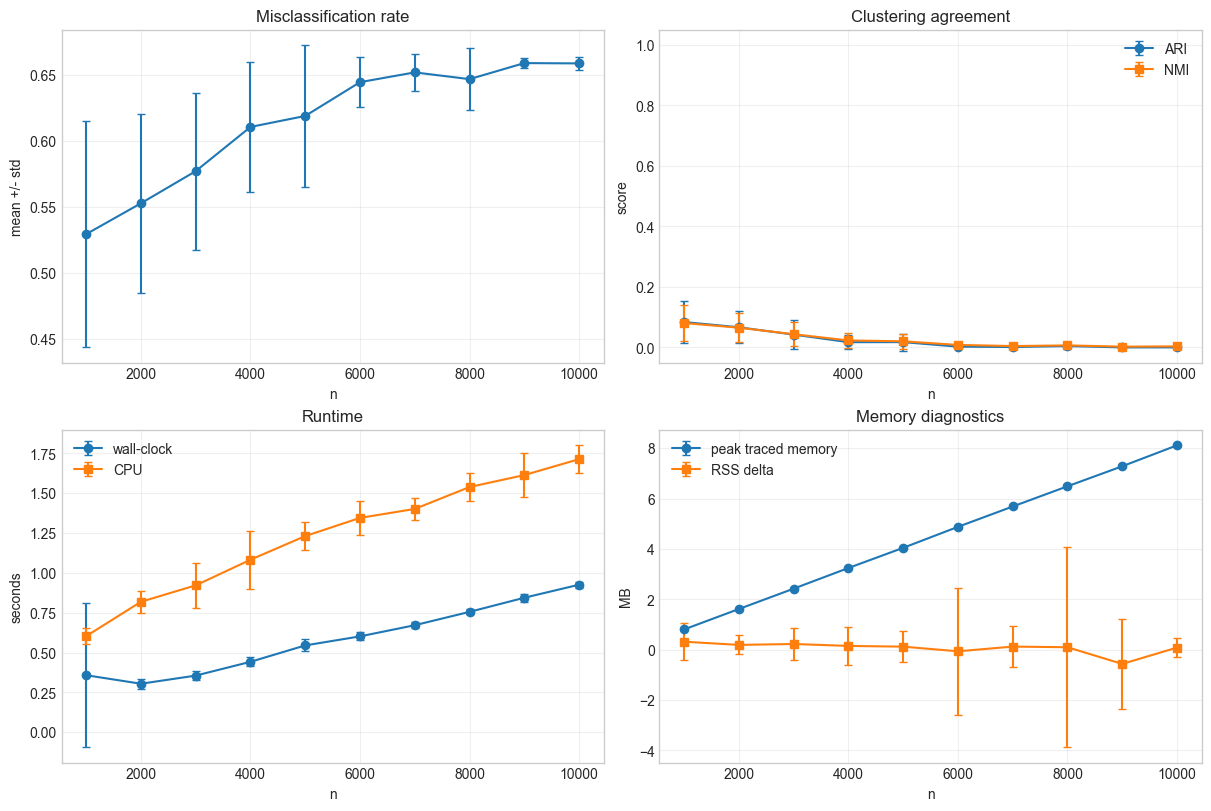

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.png')

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("n")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

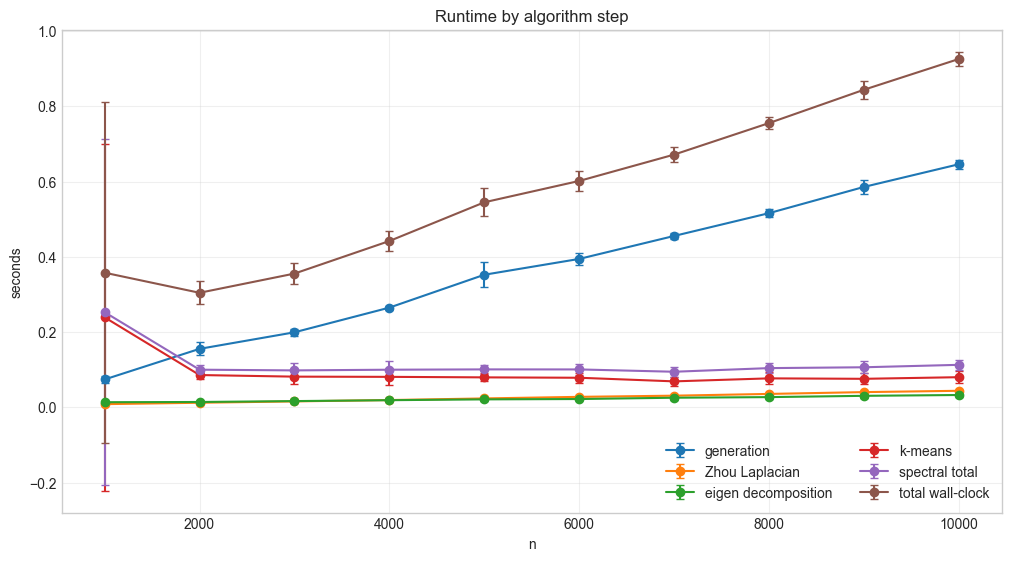

WindowsPath('c:/Users/WWindows10/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_runtime_breakdown.png')

In [16]:
x = summary["n"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("n")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## Optional: add a larger n

Uncomment and run this cell to extend the sweep. The summary cell above will need the new frame name added to its `frames` list unless you append it manually.


In [17]:
# df_n12000 = run_n_experiment(12000)